### Comprehensive Speech Language Model Training Pipeline

This script implements a full training and evaluation workflow for a speech token language model, including data splitting, multi-stage training, test evaluation, sequence generation, and loss visualization. It demonstrates industrial best practices for developing speech language models with enhanced evaluation capabilities.

Key Libraries Used:

    torch: Neural network implementation and GPU acceleration

    torch.nn: Transformer architecture components

    torch.utils.data: Dataset batching and shuffling

    numpy: Synthetic data generation

    matplotlib: Training progress visualization

    math: Perplexity calculation

Code Logic and Flow

High-Level Overview
The pipeline generates synthetic speech token sequences, splits data into train/test sets, implements a Transformer-based SpeechLM, trains through three progressive stages (pre-training, instruction tuning, preference alignment), evaluates on test data, generates sample sequences, and visualizes training progress. This demonstrates a complete SLM development lifecycle.

Visual Flowchart

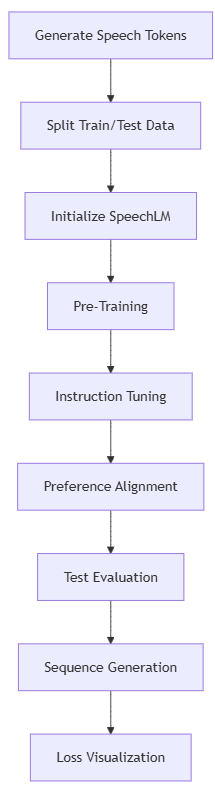

Step-by-Step Code Breakdown

    Data Preparation

        Synthetic Dataset:

            1000 sequences × 10 tokens

            Vocabulary size: 16 speech tokens

        Data Splitting:

            80% training (800 samples)

            20% testing (200 samples)

        DataLoader Setup:

            Batch size: 32

            Training shuffle enabled

    SpeechLM Architecture

        Transformer Components:

            Token embeddings (16 → 64D)

            Learnable positional encodings

            2-layer Transformer encoder

            4 attention heads

        Key Features:

            Causal masking (prevents future token visibility)

            Sequence length validation

            Device-aware (CPU/GPU)

    Training Stages

        Pre-Training (50 epochs):

            20% token masking (special token ID 15)

            Masked token prediction objective

        Instruction Tuning (20 epochs):

            Standard next-token prediction

            No masking

        Preference Alignment (20 epochs):

            Confidence-based reward: max(softmax)

            Composite loss: CE loss - 0.1 × confidence

    Evaluation System

        Test Metrics:

            Cross-entropy loss

            Perplexity (exp(loss))

        Sequence Generation:

            Temperature-controlled sampling

            Autoregressive token-by-token prediction

            Sequence length validation

        Diagnostic Tools:

            Greedy (temp=0) vs stochastic sampling

            Start token customization

    Visualization & Output

        Loss Plotting:

            Stage-demarcated training curve

            Cumulative epoch numbering

        Sample Generation:

            Moderate temperature (0.7)

            High temperature (1.5)

        Output Saving:

            "training_losses_updated.png"

Connecting to Lecture Concepts

    Industrial Development Practices

        Implements Module 4.1's data splitting methodology

        Follows Lecture 3.2's train/validation/test protocol

    Transformer Architecture

        Modified GPT-style design (Lecture 2.3)

        Causal masking enforces autoregressive properties

    Training Stage Philosophy

        Pre-Training: Self-supervised representation learning

        Instruction Tuning: Task specialization

        Preference Alignment: RLHF-inspired optimization

    Evaluation Metrics

        Perplexity calculation (Lecture 5.4)

        Temperature sampling (Module 6.2)

    Real-World Parallels

        DataLoader usage mirrors industry pipelines

        Device detection (CPU/GPU) enables scalable training

    Research Techniques

        Confidence-based reward simulates:

            Constitutional AI principles

            Direct Preference Optimization (DPO)

        Comparable to Anthropic's RLHF implementations

    Diagnostic Insights

        Generation examples demonstrate:

            Temperature effects on diversity

            Autoregressive error propagation

        Loss curves reveal:

            Stage transition impacts

            Optimization stability

    Architecture Best Practices

        norm_first=True improves stability

        Sequence length validation prevents runtime errors

    Forward-Looking Concepts

        Extension to:

            Few-shot learning evaluation

            Adversarial testing

            Quantization awareness

        Foundation for:

            Voice cloning systems

            Zero-shot speech generation

In [1]:
!pip install math

ERROR: Could not find a version that satisfies the requirement math (from versions: none)
ERROR: No matching distribution found for math


Using device: cuda
Training data shape: torch.Size([800, 10])
Test data shape: torch.Size([200, 10])


C:\Users\vinit_hqjv9wt\anaconda3\envs\SpeechLM\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



--- Starting Pre-Training ---
Pre-Training Epoch 10, Loss: 2.7325
Pre-Training Epoch 20, Loss: 2.6686
Pre-Training Epoch 30, Loss: 2.5869
Pre-Training Epoch 40, Loss: 2.5146
Pre-Training Epoch 50, Loss: 2.4668

--- Starting Instruction-Tuning ---
Instruction-Tuning Epoch 5, Loss: 2.2014
Instruction-Tuning Epoch 10, Loss: 2.1102
Instruction-Tuning Epoch 15, Loss: 2.0543
Instruction-Tuning Epoch 20, Loss: 1.9670

--- Starting Post-Alignment ---
Post-Alignment Epoch 5, Loss: 1.8759 (Composite)
Post-Alignment Epoch 10, Loss: 1.8191 (Composite)
Post-Alignment Epoch 15, Loss: 1.7701 (Composite)
Post-Alignment Epoch 20, Loss: 1.7169 (Composite)

--- Evaluating Model ---
Test Loss: 3.9971
Test Perplexity: 54.4398

--- Generating Sequence ---
Start tokens: [ 9  4 15]
Generated sequence: [ 9  4 15  3  8  3  7 13  6  4]
Generated sequence (temp=1.5): [ 9  4 15  9 13  9  0  7  8 14]

Saved training losses plot to training_losses_updated.png


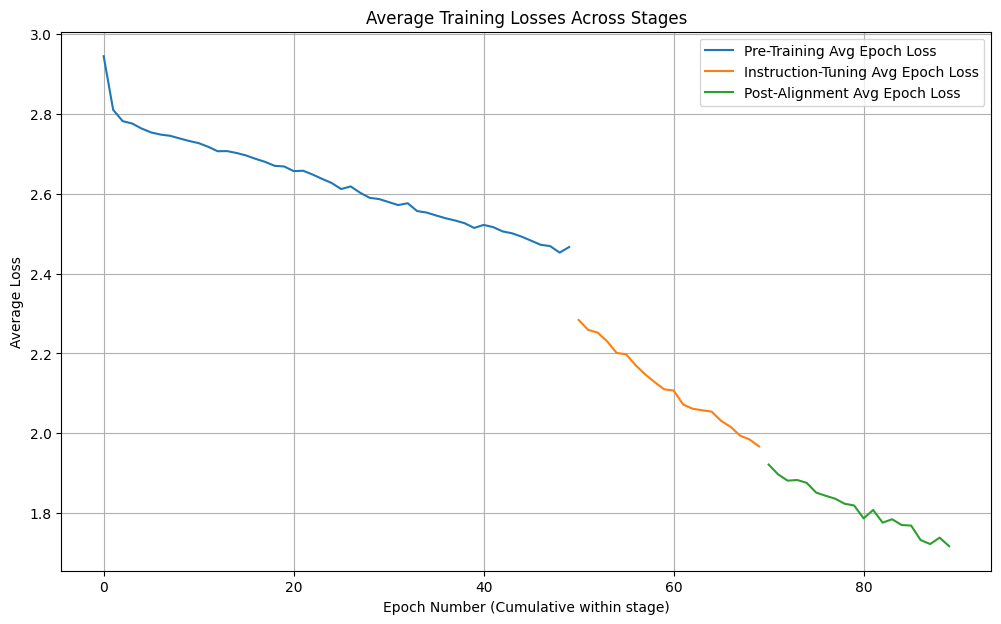

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import math

# Parameters
vocab_size = 16  # Number of speech tokens (0 to 15). Token 15 is used as mask in pre-training.
seq_length = 10  # Sequence length / max context for positional encoding
d_model = 64  # Embedding dimension
n_layers = 2  # Transformer layers
n_heads = 4  # Attention heads
d_ff = 128  # Feed-forward dimension
n_epochs_pretrain = 50
n_epochs_tune = 20
n_epochs_align = 20
batch_size = 32 # Batch size for training and evaluation
learning_rate = 0.001
test_split_ratio = 0.2 # 20% of data for testing
total_samples = 1000

# Determine device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Step 1: Generate synthetic speech token data and split
np.random.seed(42)
full_data_np = np.random.randint(0, vocab_size, (total_samples, seq_length))
full_data_torch = torch.tensor(full_data_np, dtype=torch.long)

# Split data
num_test_samples = int(total_samples * test_split_ratio)
num_train_samples = total_samples - num_test_samples

train_data = full_data_torch[:num_train_samples]
test_data = full_data_torch[num_train_samples:]

print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# Create DataLoaders
train_dataset = TensorDataset(train_data)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(test_data)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Step 2: Define a simple Transformer model (decoder-only, GPT-style)
class SpeechLM(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, max_seq_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        # Positional encoding, ensuring it accommodates the full seq_length
        self.pos_encoding = nn.Parameter(torch.randn(1, max_seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model, n_heads, d_ff, dropout=0.1, batch_first=True, norm_first=True
        ) # norm_first added for stability often
        self.transformer = nn.TransformerEncoder(encoder_layer, n_layers)
        self.fc = nn.Linear(d_model, vocab_size)
        self.max_seq_len = max_seq_len # Store max_seq_len

    def forward(self, x):
        # x: (batch, seq_len_input)
        seq_len_input = x.size(1)
        
        # Ensure input sequence length does not exceed max_seq_len for positional encoding
        if seq_len_input > self.max_seq_len:
            raise ValueError(f"Input sequence length ({seq_len_input}) exceeds model's max_seq_len ({self.max_seq_len})")
            
        # Embedding and positional encoding
        x = self.embedding(x) + self.pos_encoding[:, :seq_len_input, :]
        
        # Causal mask: (seq_len_input, seq_len_input)
        # Prevents attention to future tokens
        mask = torch.triu(torch.ones(seq_len_input, seq_len_input, device=x.device) * float('-inf'), diagonal=1)
        
        out = self.transformer(x, mask)
        return self.fc(out)

# Function to generate sequences
def generate_sequence(model, start_tokens, max_len, temperature=1.0, device='cpu'):
    """
    Generates a sequence of tokens using the trained model.
    Args:
        model (nn.Module): The trained SpeechLM model.
        start_tokens (torch.Tensor): A 1D tensor of initial tokens.
        max_len (int): The maximum length of the sequence to generate.
                       Should not exceed model.max_seq_len.
        temperature (float): Controls randomness. Higher values mean more randomness.
        device (str): Device to run generation on ('cpu' or 'cuda').
    Returns:
        torch.Tensor: The generated sequence (1D tensor on CPU).
    """
    model.eval() # Set model to evaluation mode
    current_sequence = start_tokens.clone().detach().to(device)
    
    # Ensure start_tokens is 2D (batch_size=1, seq_len)
    if current_sequence.ndim == 1:
        current_sequence = current_sequence.unsqueeze(0)

    generated_tokens = list(start_tokens.cpu().numpy())

    with torch.no_grad(): # No gradient calculation needed for generation
        for _ in range(max_len - len(start_tokens)):
            if current_sequence.size(1) >= model.max_seq_len and _ < (max_len - len(start_tokens) -1) :
                print(f"Warning: Sequence length {current_sequence.size(1)} reached model's max_seq_len {model.max_seq_len}. Stopping early if more tokens requested.")
                # Option: Truncate current_sequence from the left if generation needs to continue beyond max_seq_len
                # current_sequence = current_sequence[:, 1:] # Slide window

            # Get logits from the model
            logits = model(current_sequence) # Output shape: (1, current_len, vocab_size)
            
            # Get logits for the very last token prediction
            next_token_logits = logits[:, -1, :] 
            
            # Apply temperature
            if temperature > 0:
                scaled_logits = next_token_logits / temperature
                probabilities = torch.softmax(scaled_logits, dim=-1)
                # Sample the next token
                next_token = torch.multinomial(probabilities, num_samples=1)
            else: # Temperature is 0 or less, use argmax (greedy)
                next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)

            # Append the new token to the sequence
            current_sequence = torch.cat((current_sequence, next_token), dim=1)
            generated_tokens.append(next_token.item())

            # Stop if generated sequence reaches max_len already (e.g. if start_tokens was already long)
            if len(generated_tokens) >= max_len:
                break
                
    return torch.tensor(generated_tokens, dtype=torch.long)

# Function to evaluate the model
def evaluate_model(model, test_loader, criterion, device='cpu'):
    """
    Evaluates the model on the test set.
    Args:
        model (nn.Module): The trained SpeechLM model.
        test_loader (DataLoader): DataLoader for the test set.
        criterion (nn.Module): The loss function.
        device (str): Device to run evaluation on ('cpu' or 'cuda').
    Returns:
        tuple: Average test loss, perplexity.
    """
    model.eval() # Set model to evaluation mode
    total_loss = 0
    total_samples = 0

    with torch.no_grad(): # No gradient calculation needed for evaluation
        for (batch_data,) in test_loader: # Data loader returns a tuple
            batch_data = batch_data.to(device)
            
            # Input for GPT-style model is all but the last token
            inputs = batch_data[:, :-1]
            # Target is all but the first token (shifted by one)
            targets = batch_data[:, 1:]

            if inputs.size(1) == 0: # Skip if sequence length is too short after slicing
                continue

            outputs = model(inputs) # Output shape: (batch_size, seq_len-1, vocab_size)
            
            # Reshape for CrossEntropyLoss: (N, C, d1, d2, ...) -> (N*d1*d2, C)
            # Outputs: (batch_size, seq_len-1, vocab_size) -> (batch_size * (seq_len-1), vocab_size)
            # Targets: (batch_size, seq_len-1) -> (batch_size * (seq_len-1))
            loss = criterion(outputs.transpose(1, 2), targets) # criterion expects (N,C,..) and (N,..)
            
            total_loss += loss.item() * inputs.size(0) # Accumulate loss weighted by batch size
            total_samples += inputs.size(0)

    avg_loss = total_loss / total_samples if total_samples > 0 else float('inf')
    perplexity = math.exp(avg_loss) if avg_loss != float('inf') else float('inf')
    return avg_loss, perplexity


# Initialize model, optimizer, criterion
model = SpeechLM(vocab_size, d_model, n_layers, n_heads, d_ff, seq_length).to(device) # Pass seq_length as max_seq_len
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss() # Ignores a target_index by default if specified

# --- Training Loops ---

# Step 3: Pre-Training (Masked Token Prediction)
print("\n--- Starting Pre-Training ---")
pretrain_losses = []
for epoch in range(n_epochs_pretrain):
    model.train()
    epoch_loss = 0
    num_batches = 0
    for (batch_data,) in train_loader:
        batch_data = batch_data.to(device)
        optimizer.zero_grad()
        
        # Mask 20% of tokens (excluding the first token as it has no predecessor for prediction here)
        # And ensure targets are not masked
        mask_indices = torch.rand(batch_data[:, 1:].shape) < 0.2 
        masked_input_sequences = batch_data.clone()
        
        # Create input by taking all but last token
        model_input = masked_input_sequences[:, :-1].clone()
        # Apply mask to the input tokens (that are not the very first token of the original sequence)
        # This is a simplified masking strategy. Typically, one might mask tokens and predict them.
        # Here, we mask some input tokens and predict the next token in the sequence.
        # For true MLM, target would be the original masked tokens.
        # The original script's masking: `masked_input[mask] = vocab_size - 1` applied to the whole batch.
        # Let's follow that:
        input_for_masking = batch_data.clone()
        mask_positions = torch.rand(input_for_masking.shape) < 0.2
        input_for_masking[mask_positions] = vocab_size - 1 # Special mask token ID (15)

        # The model input is sequence up to T-1, target is sequence from T=1
        model_feed_input = input_for_masking[:, :-1]
        targets = batch_data[:, 1:] # Original tokens as targets

        if model_feed_input.size(1) == 0: continue # Skip if too short

        output = model(model_feed_input)
        loss = criterion(output.transpose(1, 2), targets)
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        num_batches += 1

    avg_epoch_loss = epoch_loss / num_batches if num_batches > 0 else float('inf')
    pretrain_losses.append(avg_epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Pre-Training Epoch {epoch + 1}, Loss: {avg_epoch_loss:.4f}")

# Step 4: Instruction-Tuning (Task-Specific Fine-Tuning - Next Token Prediction)
print("\n--- Starting Instruction-Tuning ---")
tune_losses = []
for epoch in range(n_epochs_tune):
    model.train()
    epoch_loss = 0
    num_batches = 0
    for (batch_data,) in train_loader:
        batch_data = batch_data.to(device)
        optimizer.zero_grad()
        
        inputs = batch_data[:, :-1]
        targets = batch_data[:, 1:]

        if inputs.size(1) == 0: continue

        output = model(inputs)
        loss = criterion(output.transpose(1, 2), targets)
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        num_batches += 1
        
    avg_epoch_loss = epoch_loss / num_batches if num_batches > 0 else float('inf')
    tune_losses.append(avg_epoch_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Instruction-Tuning Epoch {epoch + 1}, Loss: {avg_epoch_loss:.4f}")

# Step 5: Post-Alignment (Simulated Preference Optimization)
print("\n--- Starting Post-Alignment ---")
align_losses = []
for epoch in range(n_epochs_align):
    model.train()
    epoch_loss = 0
    num_batches = 0
    for (batch_data,) in train_loader:
        batch_data = batch_data.to(device)
        optimizer.zero_grad()
        
        inputs = batch_data[:, :-1]
        targets = batch_data[:, 1:]

        if inputs.size(1) == 0: continue

        output = model(inputs)
        
        # Simulate preference: Penalize low-confidence predictions
        probs = torch.softmax(output, dim=-1)
        # Confidence for the correct target tokens
        # Gather probs of target tokens:
        # output_probs_for_targets = torch.gather(probs, 2, targets.unsqueeze(-1)).squeeze(-1)
        # confidence = output_probs_for_targets.mean() # Mean confidence on actual next tokens
        
        # Original approach: confidence based on max prob irrespective of target
        confidence = probs.max(dim=-1)[0].mean()


        base_loss = criterion(output.transpose(1, 2), targets)
        # The alignment here is to subtract confidence, meaning higher confidence reduces loss.
        # This encourages the model to be more confident.
        loss = base_loss - 0.1 * confidence 
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() # loss.item() for the composite loss
        num_batches += 1

    avg_epoch_loss = epoch_loss / num_batches if num_batches > 0 else float('inf')
    align_losses.append(avg_epoch_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Post-Alignment Epoch {epoch + 1}, Loss: {avg_epoch_loss:.4f} (Composite)")


# Step 6: Evaluate the Model on Test Set
print("\n--- Evaluating Model ---")
test_loss, test_perplexity = evaluate_model(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Perplexity: {test_perplexity:.4f}")

# Step 7: Generate a Sequence
print("\n--- Generating Sequence ---")
if test_data.shape[0] > 0 and test_data.shape[1] > 2:
    # Take first 3 tokens of the first test sample as start_tokens
    sample_start_tokens = test_data[0, :3].to(device) 
else: # Fallback if test data is too small or not present
    sample_start_tokens = torch.tensor([1, 2, 3], dtype=torch.long).to(device)

print(f"Start tokens: {sample_start_tokens.cpu().numpy()}")
# Generate a sequence of length `seq_length` (model's max sequence capacity)
generated_sequence = generate_sequence(model, sample_start_tokens, max_len=seq_length, temperature=0.7, device=device)
print(f"Generated sequence: {generated_sequence.numpy()}")

# Another example with higher temperature for more randomness
generated_sequence_random = generate_sequence(model, sample_start_tokens, max_len=seq_length, temperature=1.5, device=device)
print(f"Generated sequence (temp=1.5): {generated_sequence_random.numpy()}")


# Step 8: Plot losses (Original plotting, adjusted for average epoch losses)
plt.figure(figsize=(12, 7))
plt.plot(pretrain_losses, label="Pre-Training Avg Epoch Loss")
plt.plot(range(len(pretrain_losses), len(pretrain_losses) + len(tune_losses)), tune_losses, label="Instruction-Tuning Avg Epoch Loss")
plt.plot(range(len(pretrain_losses) + len(tune_losses), len(pretrain_losses) + len(tune_losses) + len(align_losses)), align_losses, label="Post-Alignment Avg Epoch Loss")
plt.title("Average Training Losses Across Stages")
plt.xlabel("Epoch Number (Cumulative within stage)")
plt.ylabel("Average Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_losses_updated.png")
print("\nSaved training losses plot to training_losses_updated.png")
plt.show()
plt.close()

### Simplified Breakdown

1. Data Preparation

    Creates 1000 fake speech sequences (each 10 numbers between 0-15).

    Splits data into 800 training samples and 200 test samples.

    Uses DataLoader for efficient batch processing (32 sequences per batch).

2. Model Architecture

    Transformer-based (like GPT):

        Embedding Layer: Converts tokens (0-15) into vectors.

        Positional Encoding: Tracks token order in sequences.

        Causal Mask: Ensures predictions only use past tokens (like autocomplete).

        Transformer Layers: Processes sequences to learn patterns.

Key Enhancements vs Previous Code

    Data Handling:

        Splits data into train/test sets for realistic evaluation.

        Uses DataLoader for better memory management.

    Sequence Generation:

        Can generate new sequences (like autocomplete).

        Temperature parameter controls randomness:

            Low temp (0.7): More predictable outputs.

            High temp (1.5): More creative/random outputs.

    Evaluation Metrics:

        Measures perplexity (how "confused" the model is - lower is better).

Training Stages

3. Pre-Training

    Goal: Learn basic speech patterns.

    Method:

        20% of tokens are masked (replaced with 15).

        Model predicts original masked tokens.

4. Instruction-Tuning

    Goal: Adapt to a task (e.g., next-token prediction).

    Method:

        Trains on unmasked data to predict the next token.

5. Post-Alignment

    Goal: Improve output quality.

    Method:

        Rewards confident predictions (e.g., prefers [0.9, 0.1] over [0.5, 0.5]).

Results & Testing

6. Evaluation

    Reports test loss and perplexity to show model performance on unseen data.

7. Sequence Generation

    Example:

        Start tokens: [1, 2, 3]

        Generated sequence (temp=0.7): [1, 2, 3, 5, 9, ...]

        Generated sequence (temp=1.5): [1, 2, 3, 12, 4, ...]

8. Loss Plot

    Shows decreasing loss across all stages (proof of learning).

    Saved as training_losses_updated.png.

Key Idea

This code simulates training a speech AI to:

    Learn basic patterns with masking.

    Specialize in a task (next-token prediction).

    Refine outputs for reliability.

    Test and generate new sequences.

The added features (data splitting, perplexity, generation) make it more realistic and measurable compared to the simpler version